# 01 — Initial analysis: JKP themes as domain experts

**Which Expert, When?** First look at the US JKP panel (1990 →).

1. Build the universe (top 2000 by market cap by default) and check coverage
2. Rebuild the 13 JKP theme long-short factors from the stock-level characteristics
3. Show that theme performance is unstable over time (the motivation for gating)
4. Build naive, *unfitted* theme experts (average signed rank of each theme's characteristics)
5. Check whether expert skill depends on **stock-level** and **market-level** states — i.e. whether a gate has anything to learn

All figures are saved to `figures/` for slides. Expert scores are saved to `data/interim/` for the modeling step.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "raw").exists()), None)
assert ROOT is not None, "Run this notebook from inside the repo (couldn't find data/raw)"
RAW, INTERIM, FIG = ROOT / "data" / "raw", ROOT / "data" / "interim", ROOT / "figures"
INTERIM.mkdir(parents=True, exist_ok=True)
FIG.mkdir(exist_ok=True)

START_YEAR = 1990
UNIVERSE = "top2000"   # "top2000" | "large_mega" | "all"
TOP_N = 2000
ROLL = 36              # months, for rolling statistics

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

def save(fig, name):
    fig.savefig(FIG / f"{name}.png")

def ann_stats(r: pd.Series) -> pd.Series:
    r = r.dropna()
    return pd.Series({
        "Ann. ret %": r.mean() * 1200,
        "Ann. vol %": r.std() * np.sqrt(12) * 100,
        "Sharpe": r.mean() / r.std() * np.sqrt(12),
        "t-stat": r.mean() / r.std() * np.sqrt(len(r)),
    })

## 1. Load data and theme map

In [2]:
tm_path = RAW / "theme_map.csv"
if tm_path.exists():
    theme_map = pd.read_csv(tm_path)
else:  # rebuild from JKP's GitHub if the download script didn't save it
    gh = "https://github.com/bkelly-lab/"
    details = pd.read_excel(gh + "jkp-data/raw/main/src/jkp/data/resources/factor_details.xlsx")
    details = details[details["abr_jkp"].notna()]
    theme_map = (
        pd.read_csv(gh + "ReplicationCrisis/raw/master/GlobalFactors/Cluster%20Labels.csv")
        .merge(details[["abr_jkp", "name_new", "direction"]],
               left_on="characteristic", right_on="abr_jkp", how="left")
        .drop(columns="abr_jkp")
    )
    theme_map.to_csv(tm_path, index=False)

files = sorted(p for p in (RAW / "jkp_us").glob("*.parquet") if int(p.stem) >= START_YEAR)
raw = pd.concat((pd.read_parquet(p) for p in files), ignore_index=True)
raw["eom"] = pd.to_datetime(raw["eom"])

chars = [c for c in theme_map["characteristic"] if c in raw.columns]
raw["me"] = pd.to_numeric(raw["me"], errors="coerce").astype("float64")
raw["ret_exc_lead1m"] = pd.to_numeric(raw["ret_exc_lead1m"], errors="coerce").astype("float64")
raw[chars] = raw[chars].apply(pd.to_numeric, errors="coerce").astype("float32")

theme_map = theme_map[theme_map["characteristic"].isin(chars)].reset_index(drop=True)
theme_of = theme_map.set_index("characteristic")["cluster"]
THEMES = sorted(theme_of.unique())

print(f"Years loaded: {files[0].stem}-{files[-1].stem}")
print(f"{len(raw):,} stock-months | {raw['id'].nunique():,} stocks | {len(chars)} characteristics | {len(THEMES)} themes")
theme_of.value_counts().rename("# characteristics").to_frame().T

Years loaded: 1990-2025
2,468,282 stock-months | 26,583 stocks | 153 characteristics | 13 themes


cluster,Investment,Value,Low Risk,Quality,Seasonality,Profit Growth,Low Leverage,Profitability,Momentum,Debt Issuance,Accruals,Short-Term Reversal,Size
# characteristics,22,18,18,17,12,12,11,11,8,7,6,6,5


## 2. Universe

Universe 'top2000': 864,000 stock-months, median 2000 stocks/month


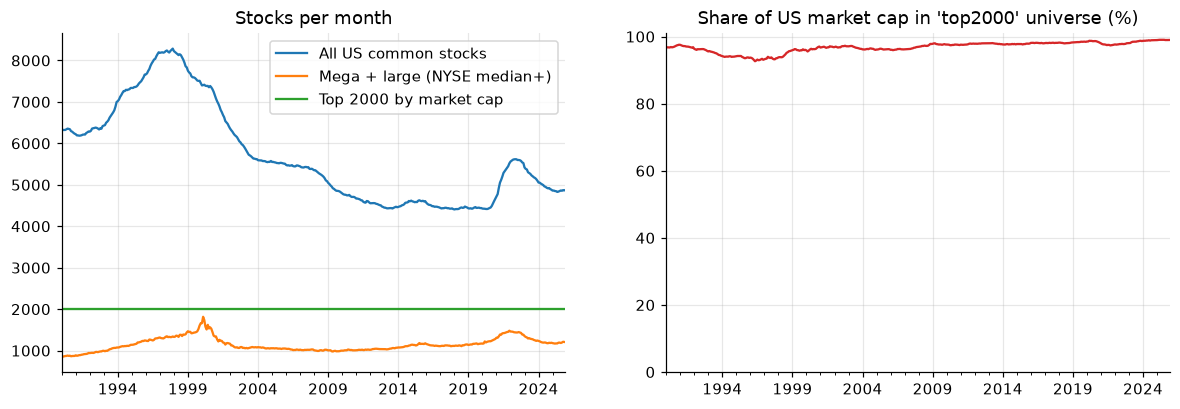

In [3]:
def select_universe(df, how=UNIVERSE, top_n=TOP_N):
    df = df[df["me"].notna()]
    if how == "top2000":
        rank = df.groupby("eom")["me"].rank(method="first", ascending=False)
        return df[rank <= top_n]
    if how == "large_mega":
        return df[df["size_grp"].isin(["large", "mega"])]
    return df

panel = select_universe(raw).sort_values(["eom", "id"]).reset_index(drop=True)
g = panel["eom"]  # month grouper used throughout

counts = pd.DataFrame({
    "All US common stocks": raw.groupby("eom")["id"].nunique(),
    "Mega + large (NYSE median+)": raw[raw["size_grp"].isin(["large", "mega"])].groupby("eom")["id"].nunique(),
    f"Top {TOP_N} by market cap": select_universe(raw, "top2000").groupby("eom")["id"].nunique(),
})
mcap_share = panel.groupby("eom")["me"].sum() / raw.groupby("eom")["me"].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
counts.plot(ax=axes[0])
axes[0].set(title="Stocks per month", xlabel="")
mcap_share.plot(ax=axes[1], color="C3")
axes[1].set(title=f"Share of US market cap in '{UNIVERSE}' universe (%)", xlabel="", ylim=(0, 101))
save(fig, "01_universe")
print(f"Universe '{UNIVERSE}': {len(panel):,} stock-months, median {counts.iloc[:, 2].median():.0f} stocks/month")

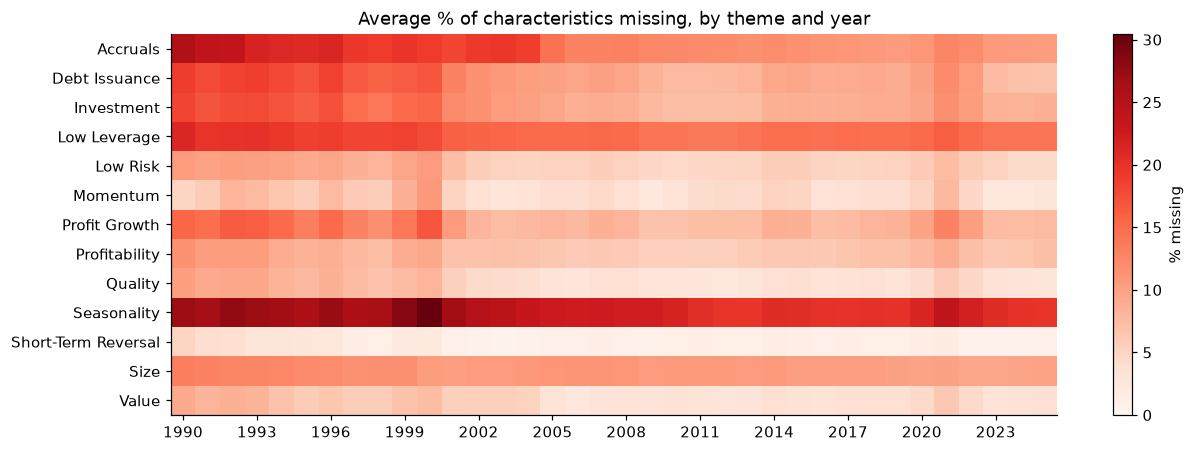

In [4]:
miss = panel[chars].isna().groupby(panel["eom"].dt.year).mean().T          # chars x years
miss_theme = miss.groupby(theme_of).mean().loc[THEMES] * 100

fig, ax = plt.subplots(figsize=(13, 4.5))
im = ax.imshow(miss_theme.values, aspect="auto", cmap="Reds", vmin=0)
ax.set_yticks(range(len(THEMES)), THEMES)
step = max(1, len(miss_theme.columns) // 12)
ax.set_xticks(range(0, len(miss_theme.columns), step), miss_theme.columns[::step])
ax.grid(False)
ax.set_title("Average % of characteristics missing, by theme and year")
fig.colorbar(im, ax=ax, label="% missing")
save(fig, "02_missingness")

## 3. Signals: signed cross-sectional ranks

Each month, every characteristic is ranked across stocks, centred to [-0.5, 0.5], and multiplied by JKP's `direction`
so that **higher = higher expected return** for every characteristic. Missing values are set to 0 (the cross-sectional median).

In [6]:
direction = theme_map.set_index("characteristic")["direction"].reindex(chars).fillna(1).astype("float32")
ranks = panel.groupby(g)[chars].rank(pct=True).astype("float32")
ranks = ((ranks - 0.5) * direction).fillna(0.0)

ret = panel["ret_exc_lead1m"]
valid = ret.notna()
me_cap = panel.groupby(g)["me"].transform(lambda s: s.clip(upper=s.quantile(0.8)))  # JKP-style capped VW
w = me_cap.where(valid, 0.0)
wr = w * ret.fillna(0.0)

def long_short(score, lo, hi):
    """Capped value-weighted long (score > hi) minus short (score < lo); indexed by formation month."""
    L, S = score > hi, score < lo
    rl = (wr * L).groupby(g).sum() / (w * L).groupby(g).sum()
    rs = (wr * S).groupby(g).sum() / (w * S).groupby(g).sum()
    return rl - rs

def to_holding(df):
    """Re-index from formation month t to the month the return is earned (t+1)."""
    out = df.copy()
    out.index = out.index + pd.offsets.MonthEnd(1)
    return out

## 4. Rebuilding the 13 JKP theme factors

Tercile long-short per characteristic (top third minus bottom third, capped value weights), then an equal-weighted average
within each theme — the JKP construction. These should line up closely with the US theme factors published on jkpfactors.com,
which is a useful check of the data pipeline.

In [8]:
char_ls = pd.DataFrame({c: long_short(ranks[c], -1/3, 1/3) for c in chars})
theme_ls = to_holding(char_ls.T.groupby(theme_of).mean().T[THEMES].dropna(how="all"))

theme_stats = theme_ls.apply(ann_stats).T.sort_values("Sharpe", ascending=False)
theme_stats.round(2)

,Ann. ret %,Ann. vol %,Sharpe,t-stat
cluster,,,,
Debt Issuance,3.47,3.43,1.01,6.06
Seasonality,1.84,2.79,0.66,3.96
Quality,4.67,8.40,0.56,3.33
Profitability,5.00,12.05,0.42,2.49
Momentum,6.17,17.39,0.35,2.13
Profit Growth,1.79,5.54,0.32,1.94
Accruals,1.42,4.59,0.31,1.85
Investment,3.46,11.45,0.30,1.81
Value,4.22,16.54,0.25,1.53


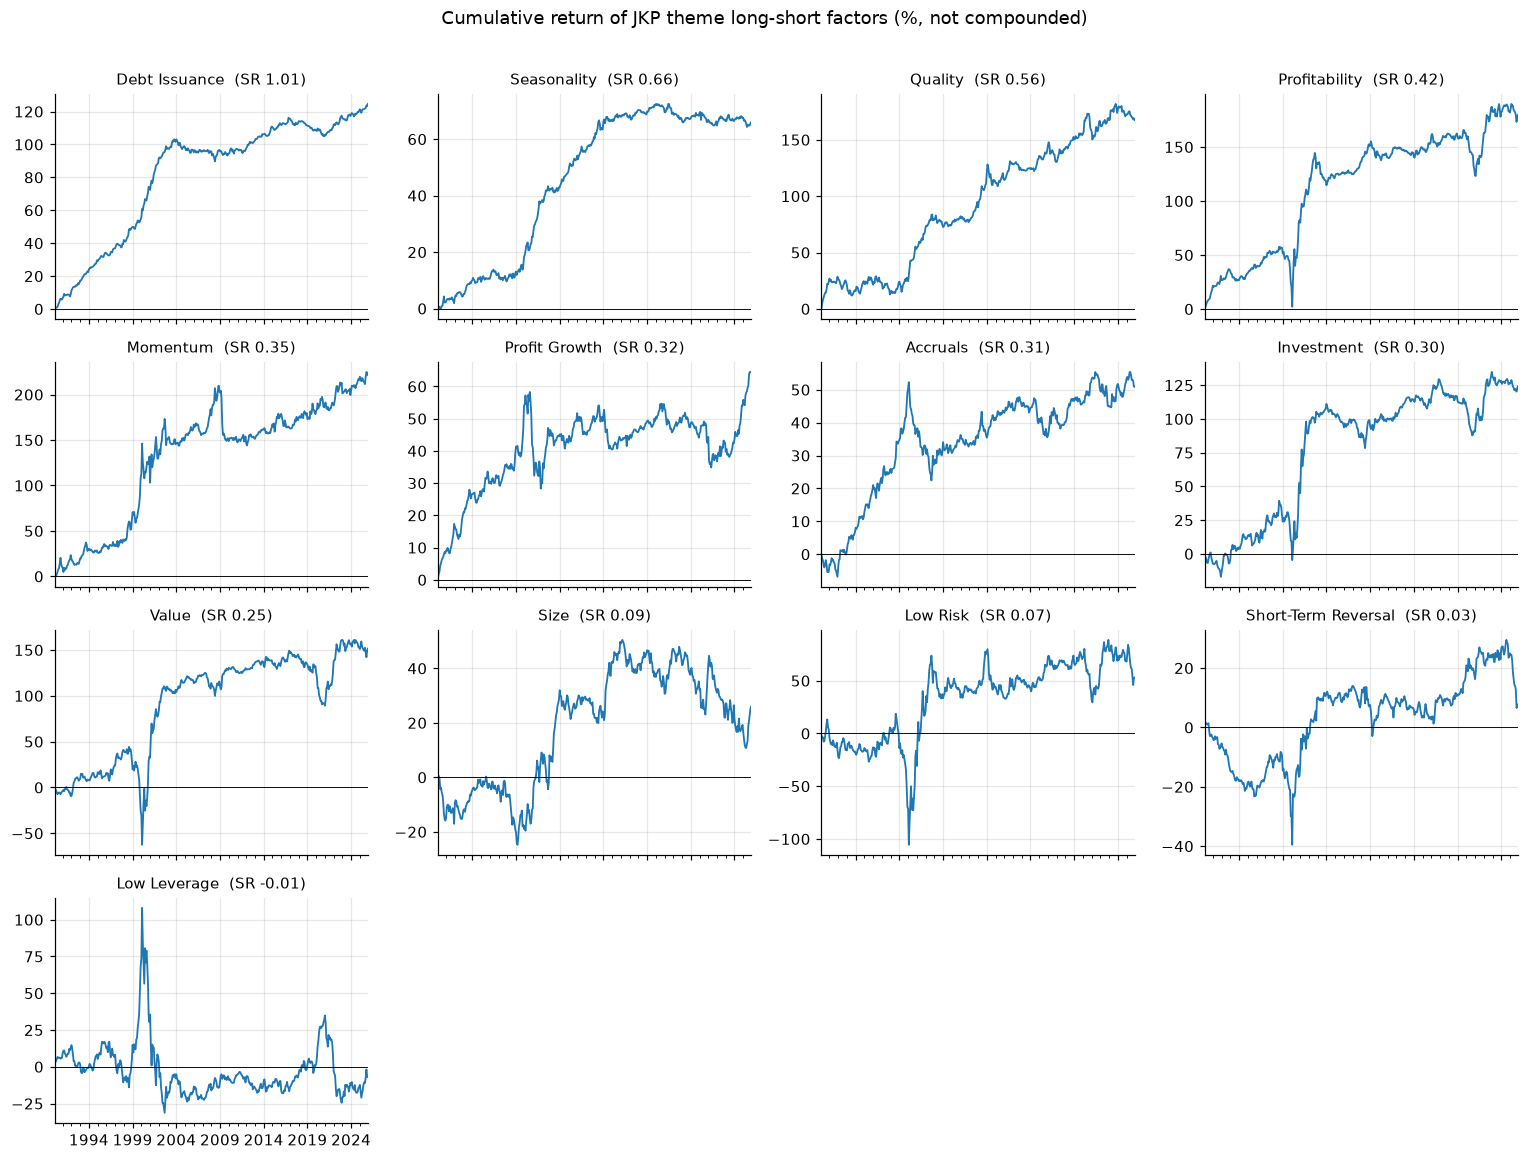

In [9]:
ncol = 4
nrow = int(np.ceil(len(THEMES) / ncol))
order = theme_stats.index
fig, axes = plt.subplots(nrow, ncol, figsize=(14, 2.6 * nrow), sharex=True)
for ax, t in zip(axes.flat, order):
    (theme_ls[t].fillna(0).cumsum() * 100).plot(ax=ax, color="C0", lw=1.2)
    ax.axhline(0, color="k", lw=0.6)
    ax.set_title(f"{t}  (SR {theme_stats.loc[t, 'Sharpe']:.2f})", fontsize=10)
    ax.set_xlabel("")
for ax in axes.flat[len(THEMES):]:
    ax.set_visible(False)
fig.suptitle("Cumulative return of JKP theme long-short factors (%, not compounded)", y=1.01)
fig.tight_layout()
save(fig, "03_theme_cumulative")

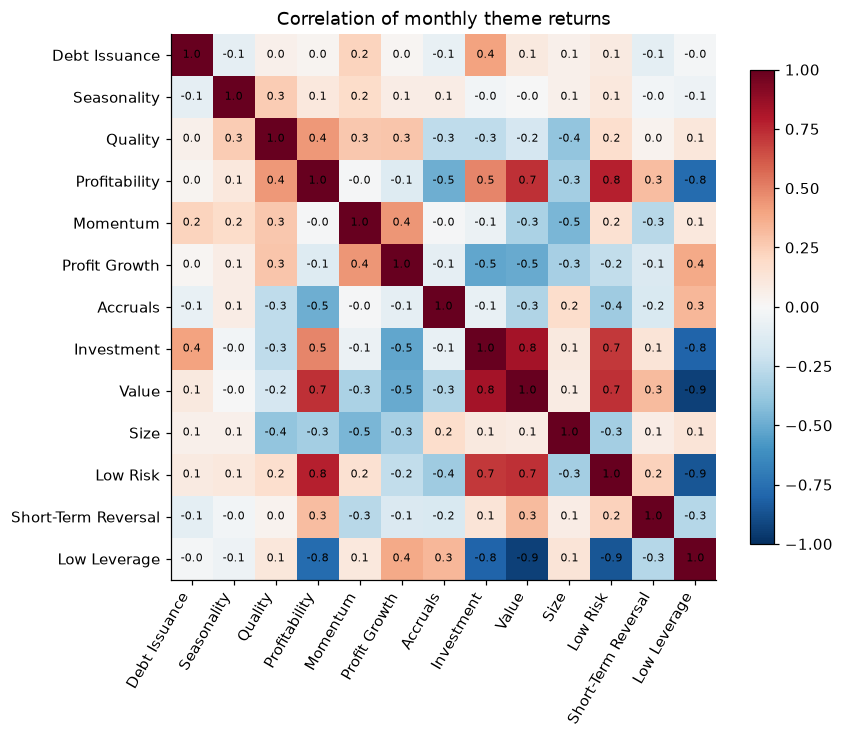

In [10]:
corr = theme_ls.corr().loc[order, order]
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(order)), order, rotation=60, ha="right")
ax.set_yticks(range(len(order)), order)
for i in range(len(order)):
    for j in range(len(order)):
        ax.text(j, i, f"{corr.values[i, j]:.1f}", ha="center", va="center", fontsize=7)
ax.grid(False)
ax.set_title("Correlation of monthly theme returns")
fig.colorbar(im, ax=ax, shrink=0.8)
save(fig, "04_theme_correlation")

### Are theme payoffs stable? Rolling Sharpe ratios

If every theme earned its premium steadily, there would be nothing for a gate to do. The heatmap shows rolling 36-month Sharpe ratios.

cluster,Debt Issuance,Seasonality,Quality,Profitability,Momentum,Profit Growth,Accruals,Investment,Value,Size,Low Risk,Short-Term Reversal,Low Leverage
% of windows with negative Sharpe,24.0,23.0,15.0,18.0,13.0,36.0,26.0,26.0,22.0,49.0,39.0,38.0,48.0


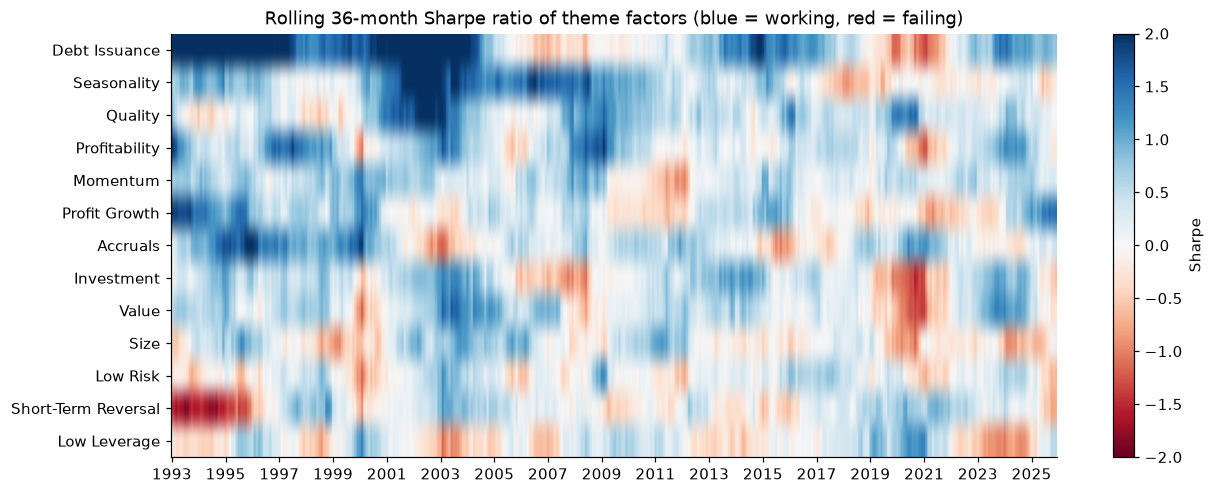

In [11]:
roll_sr = (theme_ls.rolling(ROLL).mean() / theme_ls.rolling(ROLL).std() * np.sqrt(12)).dropna(how="all")[order]

fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(roll_sr.T.values, aspect="auto", cmap="RdBu", vmin=-2, vmax=2)
ax.set_yticks(range(len(order)), order)
yrs = roll_sr.index.year
tick_pos = [i for i in range(len(yrs)) if i == 0 or yrs[i] != yrs[i - 1]]
tick_pos = tick_pos[::max(1, len(tick_pos) // 12)]
ax.set_xticks(tick_pos, yrs[tick_pos])
ax.grid(False)
ax.set_title(f"Rolling {ROLL}-month Sharpe ratio of theme factors (blue = working, red = failing)")
fig.colorbar(im, ax=ax, label="Sharpe")
save(fig, "05_rolling_sharpe")

(roll_sr < 0).mean().mul(100).round(0).rename("% of windows with negative Sharpe").to_frame().T

## 5. Naive theme experts

Expert *k*'s score for stock *i* in month *t* = average signed rank of theme *k*'s characteristics, re-ranked within the month.
No fitting yet — this is the simplest possible expert and the baseline any fitted expert must beat. `EQWT` is the equal-weighted
average of the 13 expert scores (the "no gate" benchmark).

In [12]:
expert = pd.DataFrame({t: ranks[theme_of.index[theme_of == t]].mean(axis=1) for t in THEMES})
expert = expert.groupby(g).rank(pct=True) - 0.5
expert["EQWT"] = expert[THEMES].mean(axis=1)
expert["EQWT"] = expert.groupby(g)["EQWT"].rank(pct=True) - 0.5
EXPERTS = THEMES + ["EQWT"]

def monthly_ic(scores, mask=None):
    """Spearman rank IC per month between each score column and next-month return."""
    df = scores.assign(_ret=ret)
    keep = valid if mask is None else (valid & mask)
    df, grp = df[keep], g[keep]
    return df.groupby(grp).apply(lambda d: d.corr(method="spearman")["_ret"].drop("_ret"))

ic = monthly_ic(expert[EXPERTS])
ic_stats = pd.DataFrame({
    "Mean IC": ic.mean(),
    "IC IR (ann.)": ic.mean() / ic.std() * np.sqrt(12),
    "t-stat": ic.mean() / ic.std() * np.sqrt(ic.count()),
    "% months IC>0": (ic > 0).mean() * 100,
}).sort_values("Mean IC", ascending=False)
ic_stats.round(3)

,Mean IC,IC IR (ann.),t-stat,% months IC>0
_ret,,,,
EQWT,0.037,1.371,8.216,68.213
Profitability,0.032,1.131,6.779,62.877
Value,0.030,0.622,3.729,54.988
Low Risk,0.028,0.478,2.865,53.364
Quality,0.024,0.838,5.024,61.021
Momentum,0.016,0.390,2.337,54.756
Investment,0.013,0.393,2.357,51.972
Profit Growth,0.011,0.452,2.708,58.237
Debt Issuance,0.009,0.660,3.954,59.165


,Ann. ret %,Ann. vol %,Sharpe,t-stat
EQWT,13.44,15.01,0.90,5.37
Debt Issuance,6.56,7.48,0.88,5.25
Quality,7.75,13.27,0.58,3.50
Seasonality,4.72,9.40,0.50,3.01
Profit Growth,6.08,13.52,0.45,2.69
Profitability,7.95,19.04,0.42,2.50
Accruals,3.06,8.23,0.37,2.23
Momentum,8.93,24.70,0.36,2.17
Investment,5.81,18.32,0.32,1.90
Value,4.23,27.61,0.15,0.92


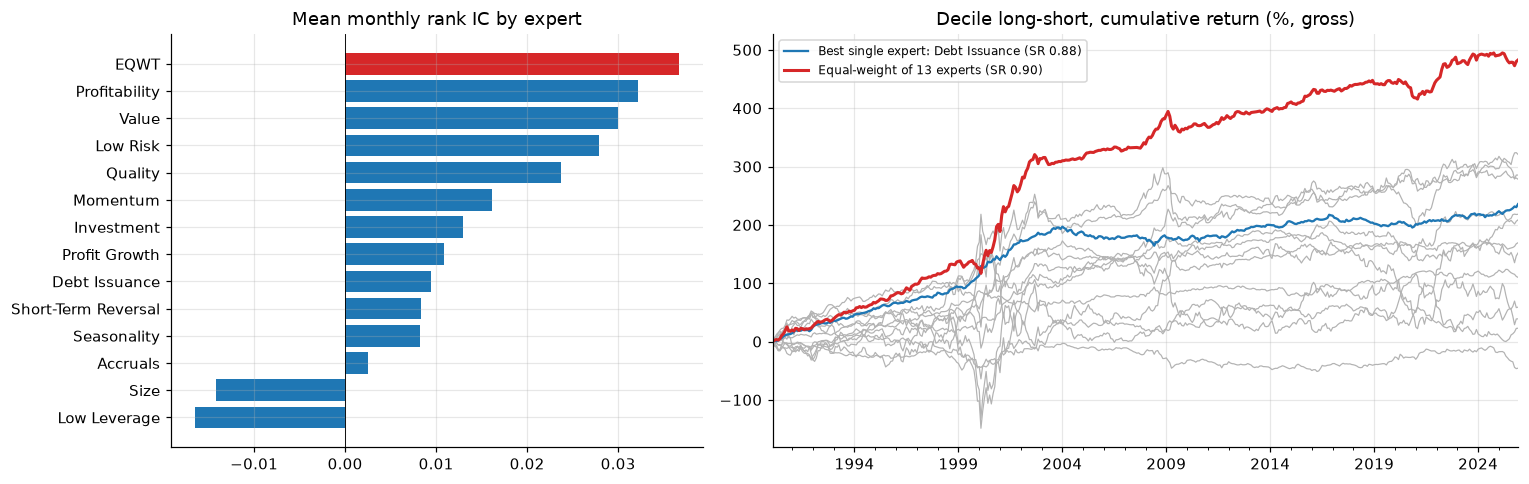

In [13]:
expert_ls = to_holding(pd.DataFrame({e: long_short(expert[e], -0.4, 0.4) for e in EXPERTS}).dropna(how="all"))
expert_stats = expert_ls.apply(ann_stats).T.sort_values("Sharpe", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={"width_ratios": [1, 1.4]})
s = ic_stats["Mean IC"].sort_values()
axes[0].barh(s.index, s.values, color=["C3" if i == "EQWT" else "C0" for i in s.index])
axes[0].set_title("Mean monthly rank IC by expert")
axes[0].axvline(0, color="k", lw=0.6)

for e in THEMES:
    (expert_ls[e].fillna(0).cumsum() * 100).plot(ax=axes[1], color="0.7", lw=0.8, label="_nolegend_")
best = expert_stats.drop("EQWT")["Sharpe"].idxmax()
(expert_ls[best].fillna(0).cumsum() * 100).plot(ax=axes[1], color="C0", lw=1.5,
    label=f"Best single expert: {best} (SR {expert_stats.loc[best, 'Sharpe']:.2f})")
(expert_ls["EQWT"].fillna(0).cumsum() * 100).plot(ax=axes[1], color="C3", lw=2,
    label=f"Equal-weight of 13 experts (SR {expert_stats.loc['EQWT', 'Sharpe']:.2f})")
axes[1].set(title="Decile long-short, cumulative return (%, gross)", xlabel="")
axes[1].legend(loc="upper left", fontsize=8)
fig.tight_layout()
save(fig, "06_expert_baselines")
expert_stats.round(2)

## 6. Which expert, when? Conditional skill

The core question for the gate: **does an expert's skill depend on the state of the stock (or the market)?**
If expert ICs look the same in every bucket, gating can't help. If they differ — especially if the *ranking* of experts changes
across buckets — there's something to learn.

### 6a. Stock-level states (the Trexquant-style gate)
Within each month, stocks are split into terciles of each state variable and expert ICs are computed within each tercile.

,Size,Volatility,Liquidity,12m return
_ret,,,,
Accruals,0.001000,-0.001000,0.004000,0.005000
Debt Issuance,0.003000,0.009000,0.005000,-0.012000
Investment,-0.007000,0.012000,0.002000,-0.024000
Low Leverage,0.019000,-0.018000,0.011000,0.012000
Low Risk,-0.028000,0.026000,-0.006000,-0.034000
Momentum,-0.008000,0.039000,0.004000,-0.008000
Profit Growth,0.002000,0.007000,0.001000,0.002000
Profitability,-0.014000,0.022000,-0.003000,-0.012000
Quality,-0.012000,0.029000,0.001000,-0.006000


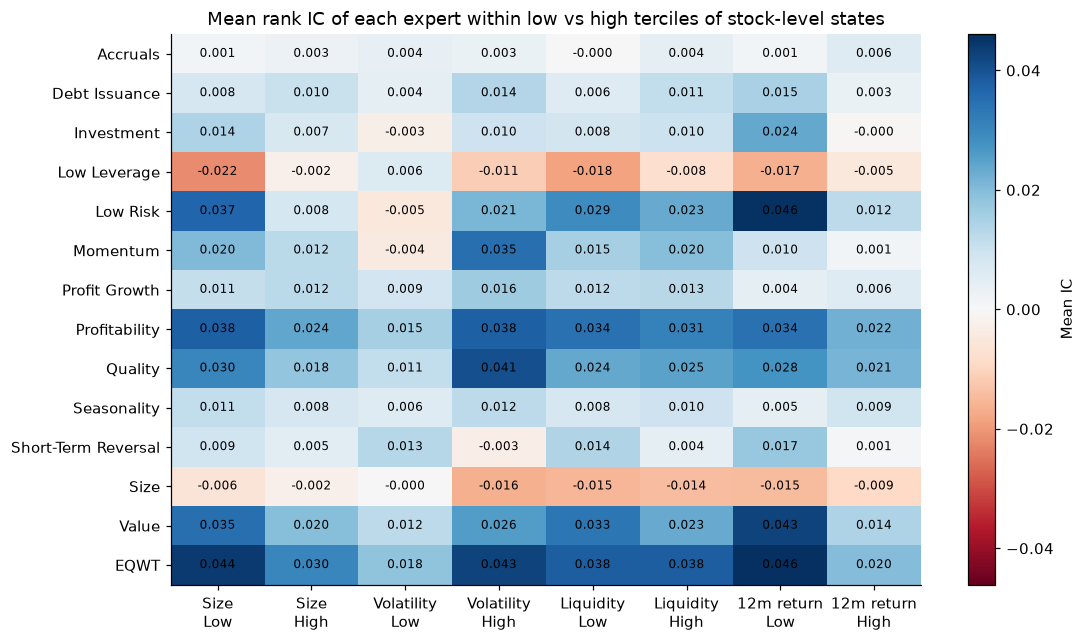

In [14]:
STATE_CANDIDATES = {
    "Size": "me",
    "Volatility": "rvol_21d",
    "Liquidity": "dolvol_126d",
    "12m return": "ret_12_1",
}
STATES = {k: v for k, v in STATE_CANDIDATES.items() if v in panel.columns}

rows = {}
for name, col in STATES.items():
    tercile = panel.groupby(g)[col].rank(pct=True)
    bucket = pd.cut(tercile, [0, 1/3, 2/3, 1], labels=["Low", "Mid", "High"])
    for b in ["Low", "High"]:
        rows[(name, b)] = monthly_ic(expert[EXPERTS], mask=(bucket == b)).mean()
cond_ic = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(11, 6.5))
vmax = np.nanmax(np.abs(cond_ic.values))
im = ax.imshow(cond_ic.values, aspect="auto", cmap="RdBu", vmin=-vmax, vmax=vmax)
ax.set_yticks(range(len(cond_ic)), cond_ic.index)
ax.set_xticks(range(cond_ic.shape[1]), [f"{a}\n{b}" for a, b in cond_ic.columns])
for i in range(cond_ic.shape[0]):
    for j in range(cond_ic.shape[1]):
        ax.text(j, i, f"{cond_ic.values[i, j]:.3f}", ha="center", va="center", fontsize=8)
ax.grid(False)
ax.set_title("Mean rank IC of each expert within low vs high terciles of stock-level states")
fig.colorbar(im, ax=ax, label="Mean IC")
save(fig, "07_conditional_ic_stock_states")

spread = pd.DataFrame({n: cond_ic[(n, "High")] - cond_ic[(n, "Low")] for n in STATES})
spread.round(3).style.background_gradient(cmap="RdBu", axis=None) if len(spread) else spread

Note: Size, Low Risk and Momentum experts contain the same variables used as states here, so their rows partly mechanically
reflect the conditioning. The cleaner evidence is for experts *unrelated* to the state (e.g. Value or Accruals across volatility terciles).

### 6b. Market-level states (the macro gate), built only from the panel itself

- **Market trend**: trailing 12-month value-weighted universe return (known at *t*), up vs down
- **Market volatility**: cross-sectional median of `rvol_21d`, above vs below its expanding median (no look-ahead)

Note the number of months in each state — this is the small-*N* problem with macro gating.

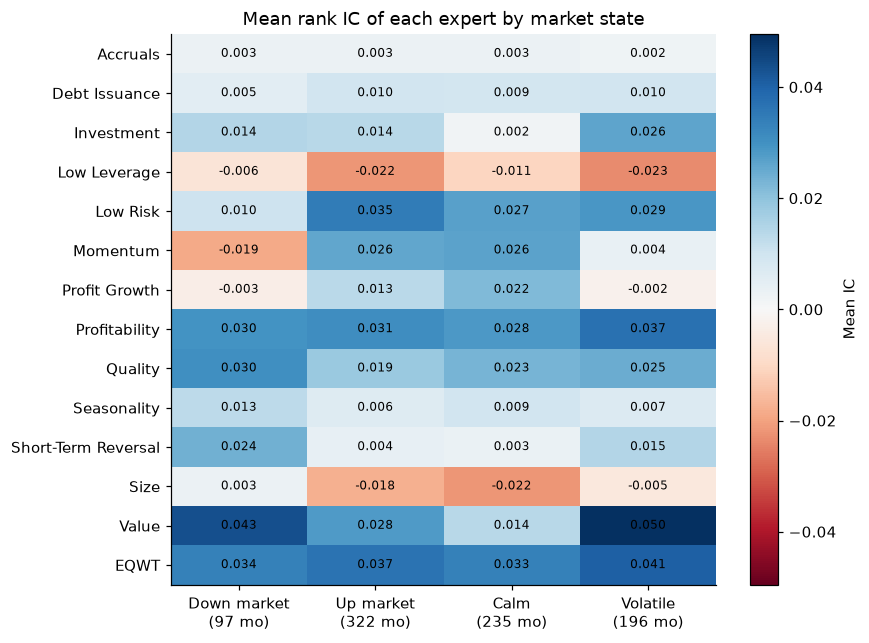

In [15]:
mkt = (wr.groupby(g).sum() / w.groupby(g).sum())              # VW universe return earned over t -> t+1
trail12 = mkt.shift(1).rolling(12).sum()                        # only returns realised by t
mstates = pd.DataFrame(index=ic.index)
mstates["Down market"] = trail12 < 0
mstates["Up market"] = trail12 >= 0
if "rvol_21d" in panel.columns:
    vol = panel.groupby(g)["rvol_21d"].median()
    hi_vol = vol > vol.expanding(12).median()
    mstates["Calm"] = ~hi_vol & vol.notna()
    mstates["Volatile"] = hi_vol
mstates = mstates.reindex(ic.index).fillna(False).astype(bool)

mkt_ic = pd.DataFrame({s: ic[mstates[s]].mean() for s in mstates})
n_months = mstates.sum()

fig, ax = plt.subplots(figsize=(8, 6.5))
vmax = np.nanmax(np.abs(mkt_ic.values))
im = ax.imshow(mkt_ic.values, aspect="auto", cmap="RdBu", vmin=-vmax, vmax=vmax)
ax.set_yticks(range(len(mkt_ic)), mkt_ic.index)
ax.set_xticks(range(mkt_ic.shape[1]), [f"{c}\n({n_months[c]} mo)" for c in mkt_ic.columns])
for i in range(mkt_ic.shape[0]):
    for j in range(mkt_ic.shape[1]):
        ax.text(j, i, f"{mkt_ic.values[i, j]:.3f}", ha="center", va="center", fontsize=8)
ax.grid(False)
ax.set_title("Mean rank IC of each expert by market state")
fig.colorbar(im, ax=ax, label="Mean IC")
save(fig, "08_conditional_ic_market_states")

## 7. Save expert scores for the modeling step

In [ ]:
out = pd.concat([panel[["id", "eom", "me", "size_grp", "ret_exc_lead1m"]],
                 expert[EXPERTS].astype("float32")], axis=1)
out.to_parquet(INTERIM / f"expert_scores_naive_{UNIVERSE}.parquet", index=False)
theme_ls.to_parquet(INTERIM / f"theme_factor_returns_{UNIVERSE}.parquet")
print(f"Saved {len(out):,} rows; figures in {FIG}")
sorted(p.name for p in FIG.glob("*.png"))

## Next steps

1. **Validate**: compare `theme_factor_returns` against the US theme factors on jkpfactors.com (correlation should be high, ~0.9+).
2. **Fitted experts**: replace the naive average with one model per theme (ridge → LightGBM), trained on expanding windows,
   saving only out-of-sample predictions.
3. **Benchmarks**: pooled model on all 153 characteristics; EQWT of fitted experts.
4. **Gates**: softmax gate on stock states, on market states, and both; soft vs top-k routing.
5. **Evaluation**: IC, long-short Sharpe, turnover, and performance after costs, on a common 1990–2023 test window.